# Практическая работа №2  
## Визуализация многомерных данных при помощи лиц Чернова  
**Вариант 5**  
**Зона:** `F_3_Z_3`

**ФИО: Решетов А.А.**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle, Arc
from sklearn.preprocessing import MinMaxScaler
import math

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = False

## 1. Загрузка данных и выбор признаков

Считаем исходный CSV-файл, переводим временную метку в формат `datetime` и выбираем признаки, относящиеся к зоне `F_3_Z_3`.

In [18]:
df = pd.read_csv('bldg-MC2.csv')
df.columns = df.columns.str.strip()

df['Date/Time'] = pd.to_datetime(df['Date/Time'])
df['Day'] = df['Date/Time'].dt.date
df['Time'] = df['Date/Time'].dt.strftime('%H:%M')

zone = 'F_3_Z_3'
features = [c for c in df.columns if c.startswith(zone)]
features


['F_3_Z_3: Lights Power',
 'F_3_Z_3: Equipment Power',
 'F_3_Z_3: Thermostat Temp',
 'F_3_Z_3: Thermostat Heating Setpoint',
 'F_3_Z_3: Thermostat Cooling Setpoint',
 'F_3_Z_3 VAV REHEAT Damper Position',
 'F_3_Z_3 REHEAT COIL Power',
 'F_3_Z_3 RETURN OUTLET CO2 Concentration',
 'F_3_Z_3 SUPPLY INLET Temperature',
 'F_3_Z_3 SUPPLY INLET Mass Flow Rate']

## 2. Краткие статистики

Для выбранной зоны вычислим среднее значение, стандартное отклонение, минимум и максимум.  
Такой обзор помогает понять диапазоны параметров перед глифовой визуализацией.

In [4]:
stats = df[features].agg(['mean', 'std', 'min', 'max']).T.round(3)
stats

,mean,std,min,max
F_3_Z_3: Lights Power,193.805,330.045,0.000,755.725
F_3_Z_3: Equipment Power,214.332,184.825,105.802,529.008
F_3_Z_3: Thermostat Temp,24.488,1.453,20.831,30.604
F_3_Z_3: Thermostat Heating Setpoint,21.028,4.042,12.600,26.670
F_3_Z_3: Thermostat Cooling Setpoint,24.130,3.223,15.560,29.700
F_3_Z_3 VAV REHEAT Damper Position,0.719,0.347,0.200,1.000
F_3_Z_3 REHEAT COIL Power,380.348,519.628,0.000,3447.964
F_3_Z_3 RETURN OUTLET CO2 Concentration,614.361,263.174,401.498,1580.862
F_3_Z_3 SUPPLY INLET Temperature,15.643,4.141,12.281,39.998
F_3_Z_3 SUPPLY INLET Mass Flow Rate,0.102,0.049,0.028,0.141


## 3. Корреляционный анализ

Построим корреляционную матрицу. Она позволяет увидеть, какие признаки изменяются согласованно, а какие — противоположно.

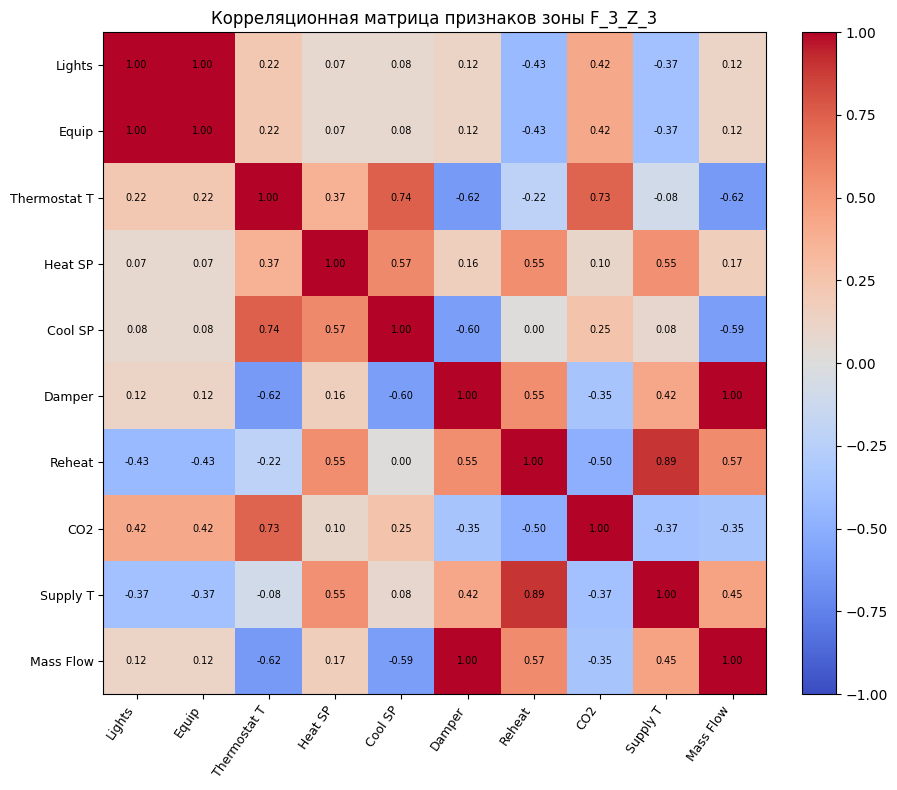

In [19]:
short_map = {
    f'{zone}: Lights Power': 'Lights',
    f'{zone}: Equipment Power': 'Equip',
    f'{zone}: Thermostat Temp': 'Thermostat T',
    f'{zone}: Thermostat Heating Setpoint': 'Heat SP',
    f'{zone}: Thermostat Cooling Setpoint': 'Cool SP',
    f'{zone} VAV REHEAT Damper Position': 'Damper',
    f'{zone} REHEAT COIL Power': 'Reheat',
    f'{zone} RETURN OUTLET CO2 Concentration': 'CO2',
    f'{zone} SUPPLY INLET Temperature': 'Supply T',
    f'{zone} SUPPLY INLET Mass Flow Rate': 'Mass Flow',
}

corr = df[features].corr()
short = [short_map[c] for c in features]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(short, rotation=55, ha='right', fontsize=9)
ax.set_yticklabels(short, fontsize=9)

for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)

ax.set_title('Корреляционная матрица признаков зоны F_3_Z_3')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

По матрице особенно выделяются несколько зависимостей:

- высокая положительная корреляция между `Lights Power` и `Equipment Power`;
- высокая положительная связь между `VAV REHEAT Damper Position` и `SUPPLY INLET Mass Flow Rate`;
- высокая положительная связь между `REHEAT COIL Power` и `SUPPLY INLET Temperature`.

Это показывает, что в зоне одновременно проявляются и режимы занятости, и вентиляционно-тепловые режимы.

## 4. Усреднение по дням и нормализация

Чтобы представить каждый день одним лицом Чернова, усредним значения параметров по дате.  
Затем применим Min–Max нормализацию, чтобы все признаки стали сопоставимыми по масштабу.

In [20]:
daily = df.groupby('Day')[features].mean()

scaler = MinMaxScaler()
daily_scaled = pd.DataFrame(
    scaler.fit_transform(daily),
    index=daily.index,
    columns=daily.columns
)

daily_scaled.head()

,F_3_Z_3: Lights Power,F_3_Z_3: Equipment Power,F_3_Z_3: Thermostat Temp,F_3_Z_3: Thermostat Heating Setpoint,F_3_Z_3: Thermostat Cooling Setpoint,F_3_Z_3 VAV REHEAT Damper Position,F_3_Z_3 REHEAT COIL Power,F_3_Z_3 RETURN OUTLET CO2 Concentration,F_3_Z_3 SUPPLY INLET Temperature,F_3_Z_3 SUPPLY INLET Mass Flow Rate
Day,,,,,,,,,,
2016-05-31,0.954128,0.954128,0.149162,0.475380,1.000000,0.077459,0.000000,0.228093,0.000279,0.077479
2016-06-01,0.770642,0.770642,0.140923,0.475380,1.000000,0.000000,0.000000,0.235788,0.000292,0.000000
2016-06-02,0.981651,0.981651,0.158059,0.475380,1.000000,0.105291,0.000000,0.244003,0.000276,0.105302
2016-06-03,0.990826,0.990826,0.145339,0.604694,0.953194,0.433811,0.196381,0.236340,0.196659,0.433829
2016-06-04,0.000000,0.000000,0.000000,1.000000,0.805541,1.000000,0.951324,0.041556,0.951269,1.000000


## 5. Средний суточный профиль

Посмотрим, как в среднем в течение суток меняются некоторые ключевые параметры зоны.

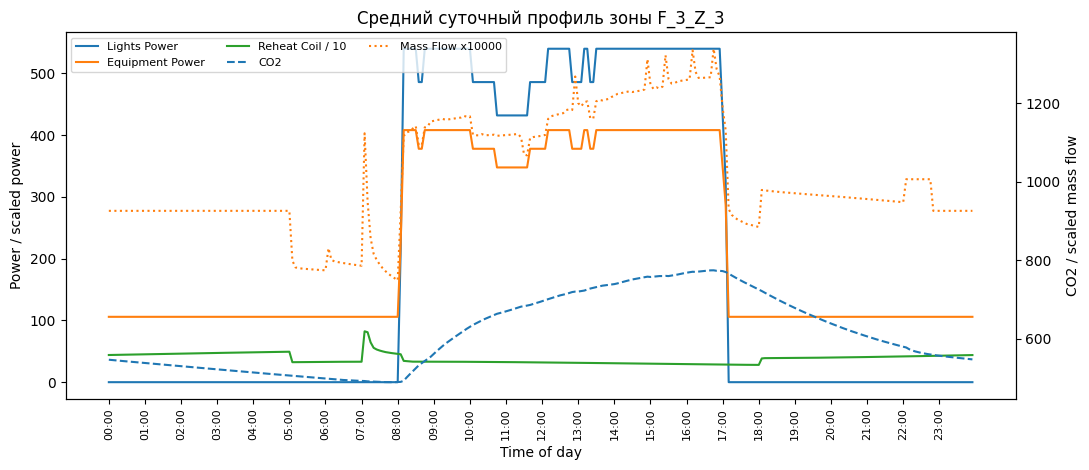

In [21]:
time_avg = df.groupby('Time')[features].mean()

fig, ax1 = plt.subplots(figsize=(11, 4.8))
ax1.plot(time_avg.index, time_avg[f'{zone}: Lights Power'], label='Lights Power')
ax1.plot(time_avg.index, time_avg[f'{zone}: Equipment Power'], label='Equipment Power')
ax1.plot(time_avg.index, time_avg[f'{zone} REHEAT COIL Power'] / 10, label='Reheat Coil / 10')
ax1.set_ylabel('Power / scaled power')
ax1.set_xlabel('Time of day')

ticks = np.arange(0, len(time_avg.index), 12)
ax1.set_xticks(ticks)
ax1.set_xticklabels(time_avg.index[ticks], rotation=90, fontsize=8)

ax2 = ax1.twinx()
ax2.plot(time_avg.index, time_avg[f'{zone} RETURN OUTLET CO2 Concentration'], linestyle='--', label='CO2')
ax2.plot(time_avg.index, time_avg[f'{zone} SUPPLY INLET Mass Flow Rate'] * 10000, linestyle=':', label='Mass Flow x10000')
ax2.set_ylabel('CO2 / scaled mass flow')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', ncol=3, fontsize=8)

ax1.set_title('Средний суточный профиль зоны F_3_Z_3')
plt.tight_layout()
plt.show()

## 6. Собственная схема лиц Чернова

Чтобы работа отличалась от примера, используем другую схему кодирования признаков:

- **ширина лица** → `Equipment Power`;
- **высота лица** → `Lights Power`;
- **размер глаз** → `Thermostat Temp`;
- **вертикальное положение глаз** → `Thermostat Heating Setpoint`;
- **наклон бровей** → `Thermostat Cooling Setpoint`;
- **длина носа** → `RETURN OUTLET CO2 Concentration`;
- **ширина рта** → `SUPPLY INLET Mass Flow Rate`;
- **изгиб рта** → `REHEAT COIL Power`;
- **смещение зрачков** → `SUPPLY INLET Temperature`.

Такое распределение удобно тем, что энергетическая нагрузка влияет на общий контур лица, а параметры микроклимата и вентиляции — на детали.

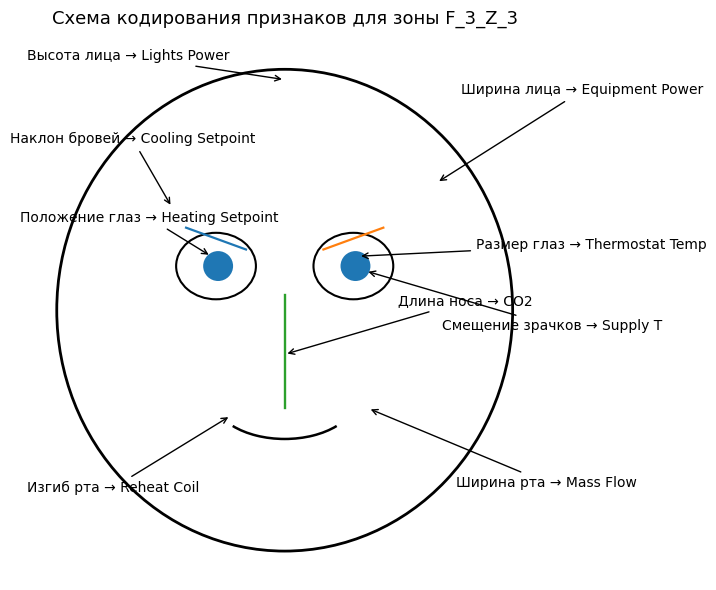

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
draw_face(ax, daily_scaled.iloc[7])

annot = dict(arrowprops=dict(arrowstyle='->'), fontsize=10)
ax.annotate('Ширина лица → Equipment Power', xy=(0.62, 0.52), xytext=(0.72, 0.88), **annot)
ax.annotate('Высота лица → Lights Power', xy=(0, 0.94), xytext=(-1.05, 1.02), **annot)
ax.annotate('Размер глаз → Thermostat Temp', xy=(0.30, 0.22), xytext=(0.78, 0.25), **annot)
ax.annotate('Положение глаз → Heating Setpoint', xy=(-0.30, 0.22), xytext=(-1.08, 0.36), **annot)
ax.annotate('Наклон бровей → Cooling Setpoint', xy=(-0.46, 0.42), xytext=(-1.12, 0.68), **annot)
ax.annotate('Длина носа → CO2', xy=(0, -0.18), xytext=(0.46, 0.02), **annot)
ax.annotate('Ширина рта → Mass Flow', xy=(0.34, -0.40), xytext=(0.70, -0.72), **annot)
ax.annotate('Изгиб рта → Reheat Coil', xy=(-0.22, -0.43), xytext=(-1.05, -0.74), **annot)
ax.annotate('Смещение зрачков → Supply T', xy=(0.33, 0.16), xytext=(0.64, -0.08), **annot)

ax.set_title('Схема кодирования признаков для зоны F_3_Z_3', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

### Схема кодирования на одном примере

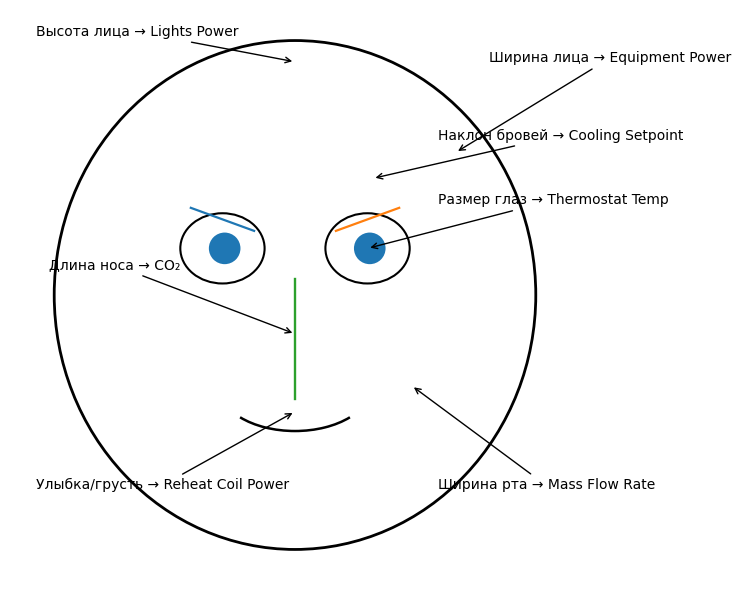

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
draw_face(ax, daily_scaled.iloc[7])

ax.annotate('Ширина лица → Equipment Power', xy=(0.62, 0.55), xytext=(0.75, 0.9),
            arrowprops=dict(arrowstyle='->'), fontsize=10)
ax.annotate('Высота лица → Lights Power', xy=(0, 0.9), xytext=(-1.0, 1.0),
            arrowprops=dict(arrowstyle='->'), fontsize=10)
ax.annotate('Размер глаз → Thermostat Temp', xy=(0.28, 0.18), xytext=(0.55, 0.35),
            arrowprops=dict(arrowstyle='->'), fontsize=10)
ax.annotate('Наклон бровей → Cooling Setpoint', xy=(0.3, 0.45), xytext=(0.55, 0.6),
            arrowprops=dict(arrowstyle='->'), fontsize=10)
ax.annotate('Длина носа → CO₂', xy=(0, -0.15), xytext=(-0.95, 0.1),
            arrowprops=dict(arrowstyle='->'), fontsize=10)
ax.annotate('Улыбка/грусть → Reheat Coil Power', xy=(0, -0.45), xytext=(-1.0, -0.75),
            arrowprops=dict(arrowstyle='->'), fontsize=10)
ax.annotate('Ширина рта → Mass Flow Rate', xy=(0.45, -0.35), xytext=(0.55, -0.75),
            arrowprops=dict(arrowstyle='->'), fontsize=10)

plt.tight_layout()
plt.show()


## 7. Визуализация 14 дней наблюдений


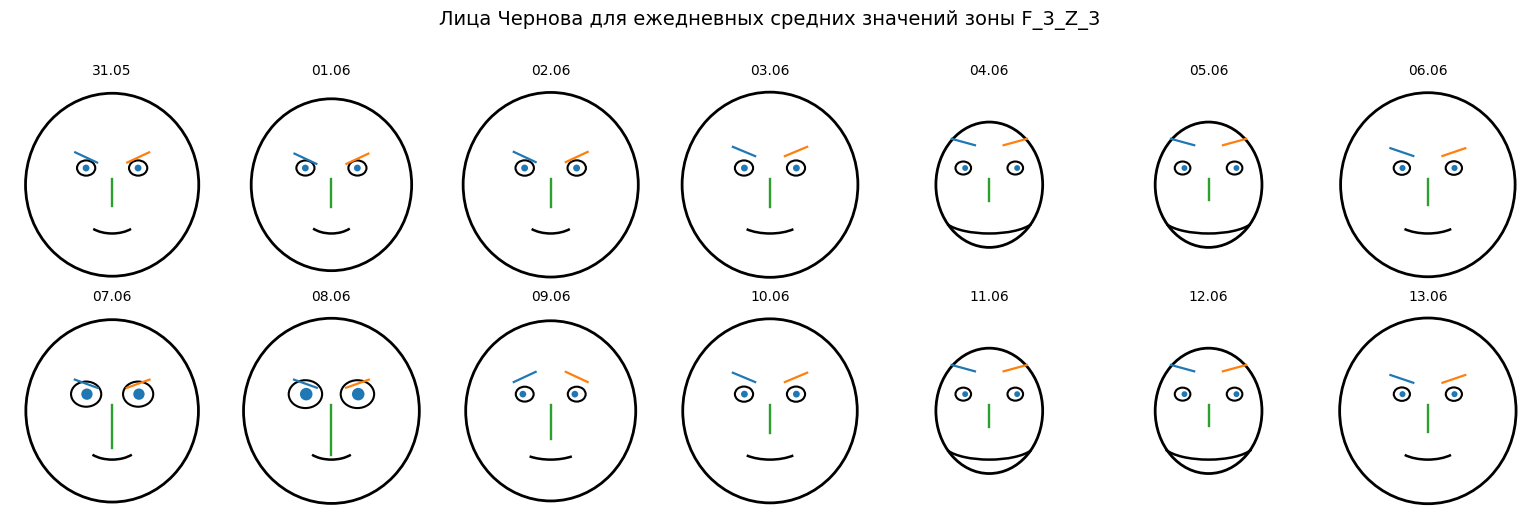

In [23]:
fig, axes = plt.subplots(2, 7, figsize=(15.5, 5.2))

for ax, (day, row) in zip(axes.flat, daily_scaled.iterrows()):
    draw_face(ax, row, pd.to_datetime(str(day)).strftime('%d.%m'))

fig.suptitle('Лица Чернова для ежедневных средних значений зоны F_3_Z_3', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Для зоны `F3_Z3_***` особенно выделяются выходные дни: лица за 04.06, 05.06, 11.06 и 12.06 имеют меньшую высоту из-за почти нулевой нагрузки по освещению, но при этом заметно отличаются по вентиляционно-тепловым параметрам.  
Кроме того, дни 07-08.06 выделяются среди рабочих дней повышенными значениями температуры и CO₂, что меняет форму глаз, носа и рта.

## 8. Формальный поиск самых необычных дней

Чтобы дополнить визуальную интерпретацию, вычислим расстояние от каждого дня до медианного состояния зоны в нормализованном пространстве признаков.

In [24]:
median_state = daily_scaled.median()
anomaly_score = ((daily_scaled - median_state) ** 2).sum(axis=1) ** 0.5

score_table = pd.DataFrame({
    'Day': daily_scaled.index.astype(str),
    'AnomalyScore': anomaly_score.round(3)
}).sort_values('AnomalyScore', ascending=False)

score_table

,Day,AnomalyScore
Day,,
2016-06-12,2016-06-12,1.990
2016-06-05,2016-06-05,1.951
2016-06-11,2016-06-11,1.947
2016-06-04,2016-06-04,1.947
2016-06-08,2016-06-08,1.265
2016-06-09,2016-06-09,1.172
2016-06-07,2016-06-07,0.995
2016-06-01,2016-06-01,0.734
2016-05-31,2016-05-31,0.599


По численной оценке наиболее необычными оказываются дни 12.06, 05.06, 11.06, 04.06 и 08.06. 
Тем самым формальный расчет подтверждает вывод, полученный визуально по лицам Чернова.

## 9. Выводы

1. Перед построением глифов данные были агрегированы по дням и нормализованы.
2. Корреляционный анализ показал тесные связи между энергетическими и вентиляционными параметрами зоны.
3. Использование собственной схемы лиц Чернова позволило сделать работу не шаблонной и удобной для визуального сравнения дней.
4. Наиболее нетипичными для зоны оказались 12.06, 05.06, 11.06, 04.06 и 08.06, что подтверждается как визуально, так и по численной оценке аномальности.